In [1]:
from sklearn.preprocessing import LabelEncoder
from imutils import paths
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from keras.models import load_model
import pickle
import pandas as pd

In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
!cp -r "/content/drive/MyDrive/dataset/RAF-DB DATASET" /content/dataset

In [15]:
#csv_path ="/content/drive/MyDrive/dataset/RAF-DB DATASET/train_labels.csv"
args = {
    "train_dir": r"/content/dataset/DATASET/train",
    "test_dir": r"/content/dataset/DATASET/test",
    "train_csv": "/content/dataset/train_labels.csv",
    "test_csv": "/content/dataset/test_labels.csv",
    "model_path": "/content/drive/MyDrive/Emotion_models/model_emotion.h5",
    "label_encoder_path": "/content/drive/MyDrive/Emotion_models/label_encoder.pkl",
    "emotion_labels_path": "/content/drive/MyDrive/Emotion_models/emotion_labels.pkl",
    "history_path" : "/content/drive/MyDrive/Emotion_models"
}

emotion_map = {
    1: "surprise",
    2: "fear",
    3: "disgust",
    4: "happy",
    5: "sad",
    6: "angry",
    7: "neutral"
}


In [5]:
# Resize ảnh
class SimplePreprocessor:
    def __init__(self, width, height, inter=cv2.INTER_AREA):
        self.width = width
        self.height = height
        self.inter = inter

    def preprocess(self, image):
        return cv2.resize(image, (self.width, self.height), interpolation=self.inter)

# Load ảnh và nhãn từ thư mục
class SimpleDatasetLoader:
    def __init__(self,csv_path ,preprocessors=None):
        self.preprocessors = preprocessors if preprocessors else []
        df = pd.read_csv(csv_path)
        # map label số -> emotion
        df["emotion"] = df["label"].map(emotion_map)
        # dictionary: filename -> emotion
        self.label_dict = dict(zip(df["image"], df["emotion"]))

    def load(self, imagePaths, verbose=-1):
        data = []
        labels = []
        for (i, imagePath) in enumerate(imagePaths):
            image = cv2.imread(imagePath)
            filename = os.path.basename(imagePath)
            label = self.label_dict.get(filename)
            if label is None:
                continue
            for p in self.preprocessors:
                image = p.preprocess(image)
            data.append(image)
            labels.append(label)
            if verbose > 0 and i > 0 and (i + 1) % verbose == 0:
                print(f"[INFO] đã xử lý {i+1}/{len(imagePaths)} ảnh")
        return (np.array(data), np.array(labels))


In [6]:
# Tải đường dẫn ảnh
print("[INFO] Đang tải ảnh...")
#imagePaths = list(paths.list_images(args["dataset"]))

# Khởi tạo bộ tiền xử lý ảnh
sp = SimplePreprocessor(100, 100)
sdl_train = SimpleDatasetLoader(args["train_csv"], preprocessors=[sp])
sdl_test = SimpleDatasetLoader(args["test_csv"], preprocessors=[sp])

# Load dữ liệu train
print("[INFO] Đang tải dữ liệu train...")
train_imagePaths = list(paths.list_images(args["train_dir"]))
(trainX, trainY) = sdl_train.load(train_imagePaths, verbose=500)
print(f"[INFO] Train data shape: {trainX.shape}")

# Load dữ liệu test
print("[INFO] Đang tải dữ liệu test...")
test_imagePaths = list(paths.list_images(args["test_dir"]))
(testX, testY) = sdl_test.load(test_imagePaths, verbose=500)
print(f"[INFO] Test data shape: {testX.shape}")

# Chuẩn hóa ảnh
trainX = trainX.astype("float32") / 255.0
testX = testX.astype("float32") / 255.0

# Mã hóa nhãn
le = LabelEncoder()
trainY = le.fit_transform(trainY)
testY = le.transform(testY)
num_classes = len(np.unique(trainY))
trainY = to_categorical(trainY, num_classes=num_classes)
testY = to_categorical(testY, num_classes=num_classes)

# Lưu label encoder và emotion_labels
os.makedirs("/content/drive/MyDrive/Emotion_models", exist_ok=True)
with open(args["label_encoder_path"], "wb") as f:
    pickle.dump(le, f)
with open(args["emotion_labels_path"], "wb") as f:
    pickle.dump(le.classes_.tolist(), f)

print("[INFO] LabelEncoder lưu")

[INFO] Đang tải ảnh...
[INFO] Đang tải dữ liệu train...
[INFO] đã xử lý 500/12275 ảnh
[INFO] đã xử lý 1000/12275 ảnh
[INFO] đã xử lý 1500/12275 ảnh
[INFO] đã xử lý 2000/12275 ảnh
[INFO] đã xử lý 2500/12275 ảnh
[INFO] đã xử lý 3000/12275 ảnh
[INFO] đã xử lý 3500/12275 ảnh
[INFO] đã xử lý 4000/12275 ảnh
[INFO] đã xử lý 4500/12275 ảnh
[INFO] đã xử lý 5000/12275 ảnh
[INFO] đã xử lý 5500/12275 ảnh
[INFO] đã xử lý 6000/12275 ảnh
[INFO] đã xử lý 6500/12275 ảnh
[INFO] đã xử lý 7000/12275 ảnh
[INFO] đã xử lý 7500/12275 ảnh
[INFO] đã xử lý 8000/12275 ảnh
[INFO] đã xử lý 8500/12275 ảnh
[INFO] đã xử lý 9000/12275 ảnh
[INFO] đã xử lý 9500/12275 ảnh
[INFO] đã xử lý 10000/12275 ảnh
[INFO] đã xử lý 10500/12275 ảnh
[INFO] đã xử lý 11000/12275 ảnh
[INFO] đã xử lý 11500/12275 ảnh
[INFO] đã xử lý 12000/12275 ảnh
[INFO] Train data shape: (12271, 100, 100, 3)
[INFO] Đang tải dữ liệu test...
[INFO] đã xử lý 500/3068 ảnh
[INFO] đã xử lý 1000/3068 ảnh
[INFO] đã xử lý 1500/3068 ảnh
[INFO] đã xử lý 2000/3068 ảnh

In [7]:
# CNN model
def cnn_model(input_shape=(100, 100, 3), num_classes=num_classes):
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [8]:
# Tạo data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(trainX)

In [9]:
# Huấn luyện
# EarlyStopping callback
earlystop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True, verbose=1)

# Huấn luyện hoặc tải mô hình đã lưu
if os.path.exists(args["model_path"]):
    print("[INFO] Đang tải mô hình đã lưu...")
    model = load_model(args["model_path"])
else:
    print("[INFO] Huấn luyện mô hình CNN từ đầu...")
    model = cnn_model()
    history = model.fit(datagen.flow(trainX, trainY, batch_size=32),
                        epochs=100,
                        validation_data=(testX, testY),
                        verbose=1,
                        #steps_per_epoch=len(trainX) // 32,
                        callbacks=[earlystop])
    print("[INFO] Lưu mô hình vào file...")
    model.save(args["model_path"])
    history_df = pd.DataFrame(history.history)
    history_df.to_csv("/content/drive/MyDrive/Emotion_models/train_history.csv", index=False)
    print("[INFO] Đã lưu history CSV")


[INFO] Huấn luyện mô hình CNN từ đầu...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 67s 132ms/step - accuracy: 0.2827 - loss: 2.7326 - val_accuracy: 0.2226 - val_loss: 3.0880
Epoch 2/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 39s 102ms/step - accuracy: 0.4212 - loss: 2.0991 - val_accuracy: 0.4844 - val_loss: 1.7905
Epoch 3/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.4647 - loss: 1.8367 - val_accuracy: 0.5241 - val_loss: 1.7992
Epoch 4/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 39s 102ms/step - accuracy: 0.4954 - loss: 1.6915 - val_accuracy: 0.4840 - val_loss: 1.6359
Epoch 5/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.5269 - loss: 1.6010 - val_accuracy: 0.5531 - val_loss: 1.5928
Epoch 6/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.5639 - loss: 1.5484 - val_accuracy: 0.6382 - val_loss: 1.3542
Epoch 7/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 40s 104ms/step - accuracy: 0.5855 - loss: 1.5056 - val_accuracy: 0.6669 - val_loss: 1.2930
Epoch 8/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 40s 104ms/step - accuracy: 0.5771 -

[INFO] Lưu mô hình vào file...
[INFO] Đã lưu history CSV


In [10]:
# Đánh giá mô hình
(loss, accuracy) = model.evaluate(testX, testY, verbose=0)
print(f"Độ chính xác mô hình trên tập test: {accuracy * 100:.2f}%")

Độ chính xác mô hình trên tập test: 82.95%


In [19]:
import pickle
import json

with open("/content/drive/MyDrive/Emotion_models/train_history.pkl", "wb") as f:
    pickle.dump(history.history, f)
print("[INFO] Đã lưu history vào", args["history_path"])


with open("/content/drive/MyDrive/Emotion_models/train_history.json", "w") as f:
    json.dump(history.history, f)
print("[INFO] Đã lưu history JSON")

[INFO] Đã lưu history vào /content/drive/MyDrive/Emotion_models
[INFO] Đã lưu history JSON


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


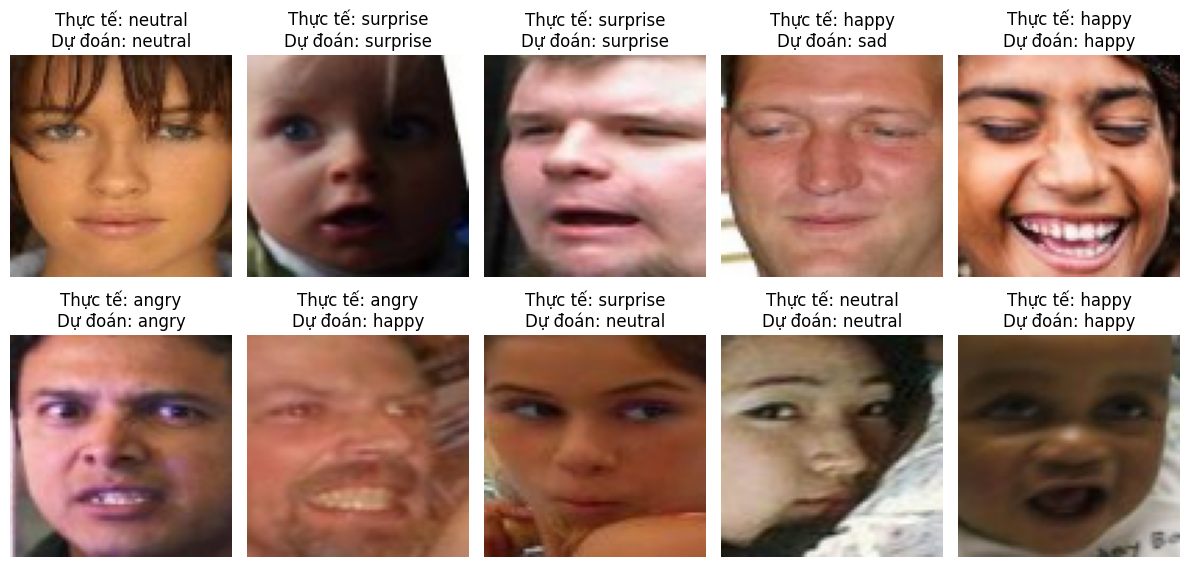

In [14]:
# Dự đoán 10 ảnh mẫu và hiển thị kết quả
sample_idxs = random.sample(range(len(testX)), 10)
sample_images = [cv2.imread(test_imagePaths[i]) for i in sample_idxs]
sample_true = [np.argmax(testY[i]) for i in sample_idxs]
predictions = model.predict(np.array([testX[i] for i in sample_idxs]))
sample_pred = [np.argmax(pred) for pred in predictions]

plt.figure(figsize=(12, 6))
for i in range(10):
    image = cv2.cvtColor(cv2.resize(sample_images[i], (80, 80)), cv2.COLOR_BGR2RGB)
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Thực tế: {le.classes_[sample_true[i]]}\nDự đoán: {le.classes_[sample_pred[i]]}")
plt.tight_layout()
plt.show()